In [ ]:
# 02_B_DASCH_Replica.ipynb - Setup
# Uses real SExtractor + astrometry.net (no Windows builds - runs in WSL2)

# Step 0 : Install WSL2 (PowerShell, as Administrator)
# wsl --install -d Ubuntu
# Restart, open "Ubuntu" from Start menu, set up username/password

# Step 1 : Install tools (Ubuntu terminal)
# sudo apt update
# sudo apt install source-extractor astrometry.net -y
# source-extractor --version
# solve-field --help

# Step 2 : Astrometry index files (Ubuntu terminal)
# sudo mkdir -p /usr/share/astrometry
# cd /usr/share/astrometry
# sudo rm -f index-41*.fits
# sudo wget https://portal.nersc.gov/project/cosmo/temp/dstn/index-5200/LITE/index-520{0..6}-42.fits
# sudo wget https://portal.nersc.gov/project/cosmo/temp/dstn/index-5200/LITE/index-520{0..6}-45.fits
# sudo wget https://portal.nersc.gov/project/cosmo/temp/dstn/index-5200/LITE/index-520{0..6}-46.fits
# grep -q "add_path /usr/share/astrometry" /etc/astrometry.cfg || echo "add_path /usr/share/astrometry" | sudo tee -a /etc/astrometry.cfg
# cat /etc/astrometry.cfg

# Step 3 : Python venv (Ubuntu terminal)
# cd ~
# python3 -m venv replica_dasch_venv
# sudo apt update
# sudo apt install -y build-essential libcairo2-dev pkg-config python3-dev
# source ~/replica_dasch_venv/bin/activate
# pip install numpy pandas matplotlib astropy photutils scipy jupyter ipywidgets ipykernel seaborn scikit-learn scikit-image
# pip install daschlab

# Step 4 : Register kernel (Ubuntu terminal)
# python -m ipykernel install --user --name=replica_dasch --display-name="Python (replica_DASCH)"

# Step 5 : VS Code
# Install from code.visualstudio.com (genuine MS VS Code, not a fork - WSL extension is MS-only)

# Step 6 : Connect (VS Code)
# Ctrl+Shift+X -> install "WSL" (Microsoft)
# Ctrl+Shift+P -> "WSL: Connect to WSL" -> confirm green WSL: Ubuntu badge
# File -> Open Folder -> notebooks folder in Windows Explorer path, opened through the WSL file picker
# With WSL badge showing, install "Python" + "Jupyter" (Microsoft) again - separate from Windows-side extensions

# Step 7 : Run (VS Code)
# Open 02_B_DASCH_Replica.ipynb -> Select Kernel -> Python (replica_DASCH) -> run Cell 1

# Reset if needed :
# rm -rf ~/replica_dasch_venv
# jupyter kernelspec uninstall replica_dasch -y

In [1]:
# 02_B_DASCH_Replica.ipynb - Cell 1
# Tool verification + SExtractor config (run this before running cell 3)

import subprocess
import shutil
from pathlib import Path

# --- Verify tools ---
SEXTRACTOR_CMD = None
for candidate in ['source-extractor', 'sextractor']:
    try:
        subprocess.run([candidate, '--version'], capture_output=True, timeout=10)
        SEXTRACTOR_CMD = candidate
        print(f"✓ SExtractor found as '{candidate}'")
        break
    except FileNotFoundError:
        continue
if SEXTRACTOR_CMD is None:
    print("❌ SExtractor not found")

try:
    subprocess.run(['solve-field', '--help'], capture_output=True, timeout=10)
    print("✓ solve-field found")
except FileNotFoundError:
    print("❌ solve-field not found")

# --- Paths ---
BASE_DATA_DIR = Path("/mnt/c/Users/dapur/Downloads/Other/Research/rcb_Star_Dust_Survey/test_CNN/data/V_CrA")
ASTROMETRY_CONFIG = Path("/etc/astrometry.cfg")

print(f"\nData dir: {BASE_DATA_DIR}")
print(f"Exists: {BASE_DATA_DIR.exists()}")
print(f"Astrometry config exists: {ASTROMETRY_CONFIG.exists()}")

# --- SExtractor config (requesting MAG_ISO) ---
EXTRACTOR_CONFIG_DIR = Path.home() / "extractor_config"
EXTRACTOR_CONFIG_DIR.mkdir(exist_ok=True)

EXTRACTOR_PARAM_FILE = EXTRACTOR_CONFIG_DIR / "default.param"
EXTRACTOR_PARAM_FILE.write_text(
    "NUMBER\nX_IMAGE\nY_IMAGE\nALPHA_J2000\nDELTA_J2000\n"
    "MAG_ISO\nMAGERR_ISO\nMAG_AUTO\nMAGERR_AUTO\nFLUX_ISO\n"
    "FLAGS\nISOAREA_IMAGE\nELONGATION\nFWHM_IMAGE\n"
)

# default.nnw - SExtractor's stock neural network file, must exist even if unused
nnw_path = EXTRACTOR_CONFIG_DIR / "default.nnw"
if not nnw_path.exists():
    result = subprocess.run(['find', '/usr', '/etc', '-name', 'default.nnw'],
                             capture_output=True, text=True, timeout=30)
    found = result.stdout.splitlines()
    if found:
        shutil.copy(found[0], nnw_path)
        print(f"✓ Copied default.nnw from {found[0]}")
    else:
        print("⚠ default.nnw not found automatically - locate it under the SExtractor "
              "install (e.g. /usr/share/source-extractor/) and copy it to:", nnw_path)

# default.conv - stock convolution kernel, REQUIRED now that FILTER=Y (matches
# DASCH's Table 2: they convolve before detecting to suppress plate grain
# noise, which is what lets them safely run a low 1.5-sigma threshold).
conv_path = EXTRACTOR_CONFIG_DIR / "default.conv"
if not conv_path.exists():
    result = subprocess.run(['find', '/usr', '/etc', '-name', 'gauss_3.0_5x5.conv'],
                             capture_output=True, text=True, timeout=30)
    found = result.stdout.splitlines()
    if found:
        shutil.copy(found[0], conv_path)
        print(f"✓ Copied default.conv from {found[0]}")
    else:
        # Fall back to writing the standard 5x5 Gaussian kernel directly -
        # this is SExtractor's own stock gauss_3.0_5x5.conv content.
        conv_path.write_text(
            "CONV NORM\n"
            "# 5x5 convolution mask of a gaussian PSF with FWHM = 3.0 pixels.\n"
            "0.092163 0.221178 0.296069 0.221178 0.092163\n"
            "0.221178 0.530797 0.710525 0.530797 0.221178\n"
            "0.296069 0.710525 0.951108 0.710525 0.296069\n"
            "0.221178 0.530797 0.710525 0.530797 0.221178\n"
            "0.092163 0.221178 0.296069 0.221178 0.092163\n"
        )
        print(f"⚠ gauss_3.0_5x5.conv not found on system - wrote the standard kernel directly to {conv_path}")

EXTRACTOR_CONFIG_FILE = EXTRACTOR_CONFIG_DIR / "default.extractor"
EXTRACTOR_CONFIG_FILE.write_text(f"""
CATALOG_NAME     out.cat
CATALOG_TYPE     ASCII_HEAD
PARAMETERS_NAME  {EXTRACTOR_PARAM_FILE}
DETECT_TYPE      CCD
DETECT_MINAREA   5
DETECT_THRESH    1.5
ANALYSIS_THRESH  1.5
FILTER           Y
FILTER_NAME      {conv_path}
DEBLEND_NTHRESH  32
DEBLEND_MINCONT  0.005
CLEAN            N
CLEAN_PARAM      1.0
MASK_TYPE        CORRECT
PHOT_APERTURES   10
PHOT_AUTOPARAMS  2.5, 3.5
SATUR_LEVEL      50000.0
MAG_ZEROPOINT    25.0
GAIN             1.0
PIXEL_SCALE      0
SEEING_FWHM      2.0
STARNNW_NAME     {EXTRACTOR_CONFIG_DIR}/default.nnw
BACKPHOTO_TYPE   LOCAL
BACK_SIZE        64
BACK_FILTERSIZE  3
VERBOSE_TYPE     QUIET
""")

print(f"\nSExtractor config: {EXTRACTOR_CONFIG_FILE}")
print(f"SExtractor params: {EXTRACTOR_PARAM_FILE}")
print("\nChanges from before, matching Laycock et al. 2010 Table 2 exactly:")
print("  DETECT_THRESH   3.0  -> 1.5   (DASCH's value - catches fainter real stars)")
print("  ANALYSIS_THRESH 3.0  -> 1.5   (kept matched to DETECT_THRESH)")
print("  FILTER          N    -> Y     (DASCH's value - suppresses grain noise, needed for the low threshold to be safe)")
print("  CLEAN           Y    -> N     (DASCH's value - keeps real stars near bright-star wings)")
print("  BACKPHOTO_TYPE  (unset) -> LOCAL  (DASCH's value - handles plate vignetting)")

✓ SExtractor found as 'source-extractor'
✓ solve-field found

Data dir: /mnt/c/Users/dapur/Downloads/Other/Research/rcb_Star_Dust_Survey/test_CNN/data/V_CrA
Exists: True
Astrometry config exists: True

SExtractor config: /home/dapur/extractor_config/default.extractor
SExtractor params: /home/dapur/extractor_config/default.param

Changes from before, matching Laycock et al. 2010 Table 2 exactly:
  DETECT_THRESH   3.0  -> 1.5   (DASCH's value - catches fainter real stars)
  ANALYSIS_THRESH 3.0  -> 1.5   (kept matched to DETECT_THRESH)
  FILTER          N    -> Y     (DASCH's value - suppresses grain noise, needed for the low threshold to be safe)
  CLEAN           Y    -> N     (DASCH's value - keeps real stars near bright-star wings)
  BACKPHOTO_TYPE  (unset) -> LOCAL  (DASCH's value - handles plate vignetting)


In [ ]:
# NOTE 02_B_DASCH_Replica.ipynb - Cell 2
# Run on synthetic unit tests

import subprocess
import shelve
import shutil
import time
import tempfile
import traceback
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from astropy.io import fits as astrofits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from IPython.display import display
import ipywidgets as widgets

UNIT_TEST_DIR = Path("/mnt/c/Users/dapur/Downloads/Other/Research/rcb_Star_Dust_Survey/test_CNN/data/unit_Tests")
CUTOUTS_DIR = UNIT_TEST_DIR / 'cutouts'
CATALOG_PATH = UNIT_TEST_DIR / 'synthetic_catalog.csv'

RUN_TIMESTAMP = time.strftime('%Y%m%d_%H%M%S')
OUTPUT_DIR = UNIT_TEST_DIR / f'test_Algorithm_{RUN_TIMESTAMP}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR = UNIT_TEST_DIR / 'algorithm_cache_02B'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_PATH = OUTPUT_DIR / 'algorithm_photometry_results.csv'
LIGHTCURVE_PATH = OUTPUT_DIR / 'algorithm_lightcurve.csv'
REF_PHOTOMETRY_PATH = OUTPUT_DIR / 'algorithm_reference_photometry.csv'

print(f"Output folder: {OUTPUT_DIR}")

MATCH_RADIUS_PX = 5.0
ISOLATION_MIN_SEPARATION = 20
REF_STARS_MAX_PER_PLATE = 150
MIN_REF_STARS = 25
LOCAL_HALF_WINDOW = 1.5
MIN_REF_STARS_LOCAL = 8
LOCAL_WINDOW_GROWTH = 1.6
MIN_ABS_LOCAL_SLOPE = 0.3
MAX_CALIBRATION_RMS = 0.3

PIPELINE_VERSION = 3

catalog = pd.read_csv(CATALOG_PATH)
target_row = catalog[catalog['is_target'] == True].iloc[0]
TARGET_COORD = SkyCoord(ra=target_row['ra'] * u.deg, dec=target_row['dec'] * u.deg)
ref_catalog = catalog[(catalog['is_target'] == False) & (catalog['is_phantom'] == False)].copy()
print(f"Loaded catalog: {len(catalog)} stars ({len(ref_catalog)} non-phantom reference candidates)")

cutouts = sorted(CUTOUTS_DIR.glob('*.fits'))
print(f"Found {len(cutouts)} plates")

if CACHE_DIR.exists():
    shutil.rmtree(CACHE_DIR)
CACHE_DIR.mkdir(parents=True)
plate_db = shelve.open(str(CACHE_DIR / 'plate_db_shelf'), flag='c', writeback=False)
print(f"Cache cleared, starting fresh")

def run_sextractor(fits_path, workdir):
    workdir = Path(workdir)
    catalog_out = workdir / f"{fits_path.stem}.cat"
    cmd = [
        SEXTRACTOR_CMD, str(fits_path),
        '-c', str(EXTRACTOR_CONFIG_FILE),
        '-CATALOG_NAME', str(catalog_out),
        '-PARAMETERS_NAME', str(EXTRACTOR_PARAM_FILE),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=60)
    if not catalog_out.exists():
        return None, result.stderr

    colnames = []
    with open(catalog_out) as f:
        for line in f:
            if line.startswith('#'):
                colnames.append(line.split()[2])
            else:
                break
    if not colnames:
        return None, "empty catalog"
    df = pd.read_csv(catalog_out, comment='#', sep=r'\s+', names=colnames)
    return df, None

def filter_isolated(x, y, min_sep=ISOLATION_MIN_SEPARATION):
    n = len(x)
    if n < 2:
        return np.ones(n, dtype=bool)
    isolated = np.ones(n, dtype=bool)
    for i in range(n):
        d = np.hypot(x - x[i], y - y[i])
        d[i] = np.inf
        if np.any(d < min_sep):
            isolated[i] = False
    return isolated

def calibrate_global(inst_mags, apass_b, min_stars=MIN_REF_STARS):
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    if mask.sum() < min_stars:
        return None
    x, y = apass_b[mask], inst_mags[mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 2)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < 3.0 * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 2)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def calibrate_local(inst_mags, apass_b, target_b_estimate,
                     half_window=LOCAL_HALF_WINDOW, min_stars=MIN_REF_STARS_LOCAL,
                     growth=LOCAL_WINDOW_GROWTH):
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    x_all, y_all = apass_b[mask], inst_mags[mask]
    if len(x_all) < min_stars:
        return None
    window = half_window
    local_mask = np.abs(x_all - target_b_estimate) <= window
    for _ in range(5):
        if local_mask.sum() >= min_stars:
            break
        window *= growth
        local_mask = np.abs(x_all - target_b_estimate) <= window
    if local_mask.sum() < min_stars:
        return None
    x, y = x_all[local_mask], y_all[local_mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 1)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < 3.0 * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 1)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x), 'window_used': float(window),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def invert_calibration(calibration, t_inst_mag):
    coeffs = list(calibration['coeffs'])
    coeffs[-1] -= t_inst_mag
    roots = np.roots(coeffs)
    real_roots = roots[np.abs(roots.imag) < 1e-6].real
    if len(real_roots) == 0:
        return None
    lo, hi = calibration['b_min'], calibration['b_max']
    in_range = real_roots[(real_roots >= lo - 2) & (real_roots <= hi + 2)]
    candidates = in_range if len(in_range) > 0 else real_roots
    return float(min(candidates, key=lambda r: abs(np.polyval(calibration['coeffs'], r) - t_inst_mag)))

def process_plate(fits_path):
    try:
        plate_rng = np.random.default_rng(abs(hash(fits_path.name)) % (2**32))
        header = astrofits.getheader(fits_path)
        wcs = WCS(header)
        jd = header.get('JD-OBS', np.nan)
        h, w = astrofits.getdata(fits_path).shape

        with tempfile.TemporaryDirectory() as workdir:
            sources, err = run_sextractor(fits_path, workdir)
        if sources is None or len(sources) == 0:
            return _empty_result(fits_path, jd, f'SExtractor found nothing ({err})')

        det_x = sources['X_IMAGE'].values
        det_y = sources['Y_IMAGE'].values
        det_mag_iso = sources['MAG_ISO'].values
        det_flags = sources['FLAGS'].values.astype(int)
        is_saturated_flag = (det_flags & 4) != 0

        ra = ref_catalog['ra'].values
        dec = ref_catalog['dec'].values
        apass_b_all = ref_catalog['apass_b_mag'].values
        cat_x, cat_y = wcs.all_world2pix(ra, dec, 0)
        margin = 20
        in_frame = (cat_x > margin) & (cat_x < w - margin) & (cat_y > margin) & (cat_y < h - margin)
        cat_x, cat_y, apass_b_all = cat_x[in_frame], cat_y[in_frame], apass_b_all[in_frame]

        if len(cat_x) > REF_STARS_MAX_PER_PLATE:
            keep = plate_rng.choice(len(cat_x), size=REF_STARS_MAX_PER_PLATE, replace=False)
            cat_x, cat_y, apass_b_all = cat_x[keep], cat_y[keep], apass_b_all[keep]

        matched_inst_mag, matched_apass_b, matched_x, matched_y, matched_sat = [], [], [], [], []
        for cx, cy, ab in zip(cat_x, cat_y, apass_b_all):
            d = np.hypot(det_x - cx, det_y - cy)
            j = np.argmin(d)
            if d[j] <= MATCH_RADIUS_PX:
                matched_inst_mag.append(det_mag_iso[j])
                matched_apass_b.append(ab)
                matched_x.append(det_x[j])
                matched_y.append(det_y[j])
                matched_sat.append(is_saturated_flag[j])

        if len(matched_inst_mag) == 0:
            return _empty_result(fits_path, jd, 'No SExtractor detections matched catalog stars')

        matched_inst_mag = np.array(matched_inst_mag)
        matched_apass_b = np.array(matched_apass_b)
        matched_x = np.array(matched_x)
        matched_y = np.array(matched_y)
        matched_sat = np.array(matched_sat)

        isolated = filter_isolated(matched_x, matched_y)
        good_for_fit = isolated & ~matched_sat & np.isfinite(matched_inst_mag)

        calibration_global = calibrate_global(matched_inst_mag[good_for_fit], matched_apass_b[good_for_fit])
        n_ref_used = calibration_global['n_used'] if calibration_global else int(good_for_fit.sum())

        ref_rows = []
        for i in np.where(good_for_fit)[0]:
            ref_rows.append({'filename': fits_path.name, 'star_id': f'MATCH_{i:04d}',
                              'apass_b_mag': matched_apass_b[i], 'instrumental_mag': matched_inst_mag[i]})

        tx, ty = wcs.all_world2pix(TARGET_COORD.ra.deg, TARGET_COORD.dec.deg, 0)
        target_detected = False
        target_mag = np.nan
        target_mag_error = np.nan
        calibration_mode = None
        final_rms = np.nan
        final_n_used = 0

        if margin < tx < w - margin and margin < ty < h - margin and calibration_global is not None:
            d = np.hypot(det_x - tx, det_y - ty)
            j = np.argmin(d)
            if d[j] <= MATCH_RADIUS_PX:
                t_inst_mag = det_mag_iso[j]
                rough_mag = invert_calibration(calibration_global, t_inst_mag)
                if rough_mag is not None:
                    calibration_local = calibrate_local(matched_inst_mag[good_for_fit],
                                                          matched_apass_b[good_for_fit], rough_mag)
                    if (calibration_local is not None
                            and abs(calibration_local['coeffs'][0]) >= MIN_ABS_LOCAL_SLOPE):
                        local_mag = invert_calibration(calibration_local, t_inst_mag)
                        if local_mag is not None:
                            target_mag = local_mag
                            final_rms = calibration_local['rms']
                            final_n_used = calibration_local['n_used']
                            calibration_mode = 'local'
                    if calibration_mode is None:
                        target_mag = rough_mag
                        final_rms = calibration_global['rms']
                        final_n_used = calibration_global['n_used']
                        calibration_mode = 'global_fallback'
                    target_mag_error = final_rms / np.sqrt(max(final_n_used, 1))
                    target_detected = True

        quality_ok = (
            calibration_global is not None and n_ref_used >= MIN_REF_STARS and
            target_detected and calibration_mode == 'local' and
            np.isfinite(final_rms) and final_rms <= MAX_CALIBRATION_RMS
        )

        rejection_reason = None
        if calibration_global is None:
            rejection_reason = 'Global calibration failed'
        elif n_ref_used < MIN_REF_STARS:
            rejection_reason = f'Too few reference stars ({n_ref_used} < {MIN_REF_STARS})'
        elif not target_detected:
            rejection_reason = 'Target not detected/matched'
        elif calibration_mode != 'local':
            rejection_reason = 'Local calibration unavailable'
        elif final_rms > MAX_CALIBRATION_RMS:
            rejection_reason = f'RMS too high ({final_rms:.3f})'

        result_row = {
            'filename': fits_path.name, 'jd': jd, 'target_detected': target_detected,
            'target_mag': target_mag, 'target_mag_error': target_mag_error,
            'target_x': float(tx), 'target_y': float(ty),
            'num_reference_stars': n_ref_used,
            'zeropoint': calibration_global['coeffs'][-1] if calibration_global else np.nan,
            'rms_scatter': final_rms,
            'calibration_mode': calibration_mode, 'quality_ok': quality_ok,
            'rejection_reason': rejection_reason,
        }
        return {'result_row': result_row, 'ref_rows': ref_rows}

    except Exception as e:
        return _empty_result(fits_path, np.nan, str(e))

def _empty_result(fits_path, jd, reason):
    return {'result_row': {
        'filename': fits_path.name, 'jd': jd, 'target_detected': False,
        'target_mag': np.nan, 'target_mag_error': np.nan, 'target_x': np.nan, 'target_y': np.nan,
        'num_reference_stars': 0, 'zeropoint': np.nan, 'rms_scatter': np.nan,
        'calibration_mode': None, 'quality_ok': False, 'rejection_reason': reason,
    }, 'ref_rows': []}

progress_bar = widgets.IntProgress(value=0, min=0, max=len(cutouts), description='Plates:')
progress_html = widgets.HTML(value="")
display(widgets.VBox([progress_bar, progress_html]))

start = time.monotonic()
last_render = 0.0
n_processed = 0
for i, f in enumerate(cutouts):
    key = str(f)
    cached = plate_db.get(key)
    if not (cached and cached.get('_version', 0) == PIPELINE_VERSION):
        out = process_plate(f)
        out['_version'] = PIPELINE_VERSION
        plate_db[key] = out
        n_processed += 1

    now = time.monotonic()
    if now - last_render > 0.15 or (i + 1) == len(cutouts):
        elapsed = now - start
        rate = (i + 1) / elapsed if elapsed > 0 else 0
        progress_bar.value = i + 1
        progress_html.value = f"{i+1}/{len(cutouts)} ({rate:.2f} plates/sec)"
        last_render = now

    if (i + 1) % 200 == 0:
        plate_db.sync()

plate_db.sync()
print(f"Processed {n_processed} plates this run, {len(plate_db)} total in cache")

current_keys = {str(f) for f in cutouts}
result_rows, ref_rows_all = [], []
for f_str in plate_db.keys():
    if f_str not in current_keys:
        continue
    out = plate_db[f_str]
    if out is None or out.get('_version') != PIPELINE_VERSION:
        continue
    result_rows.append(out['result_row'])
    ref_rows_all.extend(out['ref_rows'])

print(f"Collected {len(result_rows)} result rows for saving")

if len(result_rows) == 0:
    print("ERROR: No results collected. Something went wrong in the processing loop above.")
else:
    results_df = pd.DataFrame(result_rows).sort_values('jd').reset_index(drop=True)
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Saved {RESULTS_PATH.name} ({len(results_df)} plates)")

    ref_df = pd.DataFrame(ref_rows_all)
    ref_df.to_csv(REF_PHOTOMETRY_PATH, index=False)
    print(f"Saved {REF_PHOTOMETRY_PATH.name} ({len(ref_df)} reference measurements)")

    lc_df = results_df[results_df['quality_ok']].copy()
    lc_df = lc_df.rename(columns={'target_mag': 'magnitude', 'target_mag_error': 'magnitude_error'})
    lc_df = lc_df[['jd', 'magnitude', 'magnitude_error']].dropna()
    lc_df.to_csv(LIGHTCURVE_PATH, index=False)
    print(f"Saved {LIGHTCURVE_PATH.name} ({len(lc_df)} light curve points)")

    print(f"\nCalibration mode breakdown: {results_df['calibration_mode'].value_counts(dropna=False).to_dict()}")
    print(f"\nTo validate: open unit_Test_Generator.ipynb, set USE_SIMULATED_INPUTS=False, run Cell 2")
    print(f"It will auto-discover: {OUTPUT_DIR.name}")

Output folder: /mnt/c/Users/dapur/Downloads/Other/Research/rcb_Star_Dust_Survey/test_CNN/data/V_CrA/02_B/run_20260811_134343
Found 5402 V CrA plates total, using 200 this run (PLATE_LIMIT=200)
Loaded 5402 cached plate results, 220 cached APASS field queries
Using 8 concurrent workers


0 plates already cached, 200 to process this run with 8 workers
Processed 200 plates this run, 5402 total in cache
solve-field succeeded on 45/200 freshly-processed plates (22.5%)
Total run time: 6:07
Collected 200 result rows for saving
Saved vcra_photometry_results.csv (200 plates)
Saved vcra_reference_photometry.csv (7480 reference measurements)
magnitude_error distribution: median=0.0999, min=0.0280, max=0.3313 (compare to the ~17.5-mag y-axis range - this is likely why bars look invisible)
Saved vcra_lightcurve.csv (18 light curve points)
Saved vcra_upper_limits.csv (5 upper limits - target too faint to detect on these plates)

Calibration mode breakdown: {nan: 160, 'local': 38, 'global_fallback': 2}
astrometry_solved breakdown: {False: 155, True: 45}
distortion_refined breakdown: {True: 188, False: 12}
target_match_forced (needed the permissive fallback): 8 of 40 total detections

*** RMS DISTRIBUTION among all 40 target-detected plates ***
count    40.000000
mean      1.207813
s

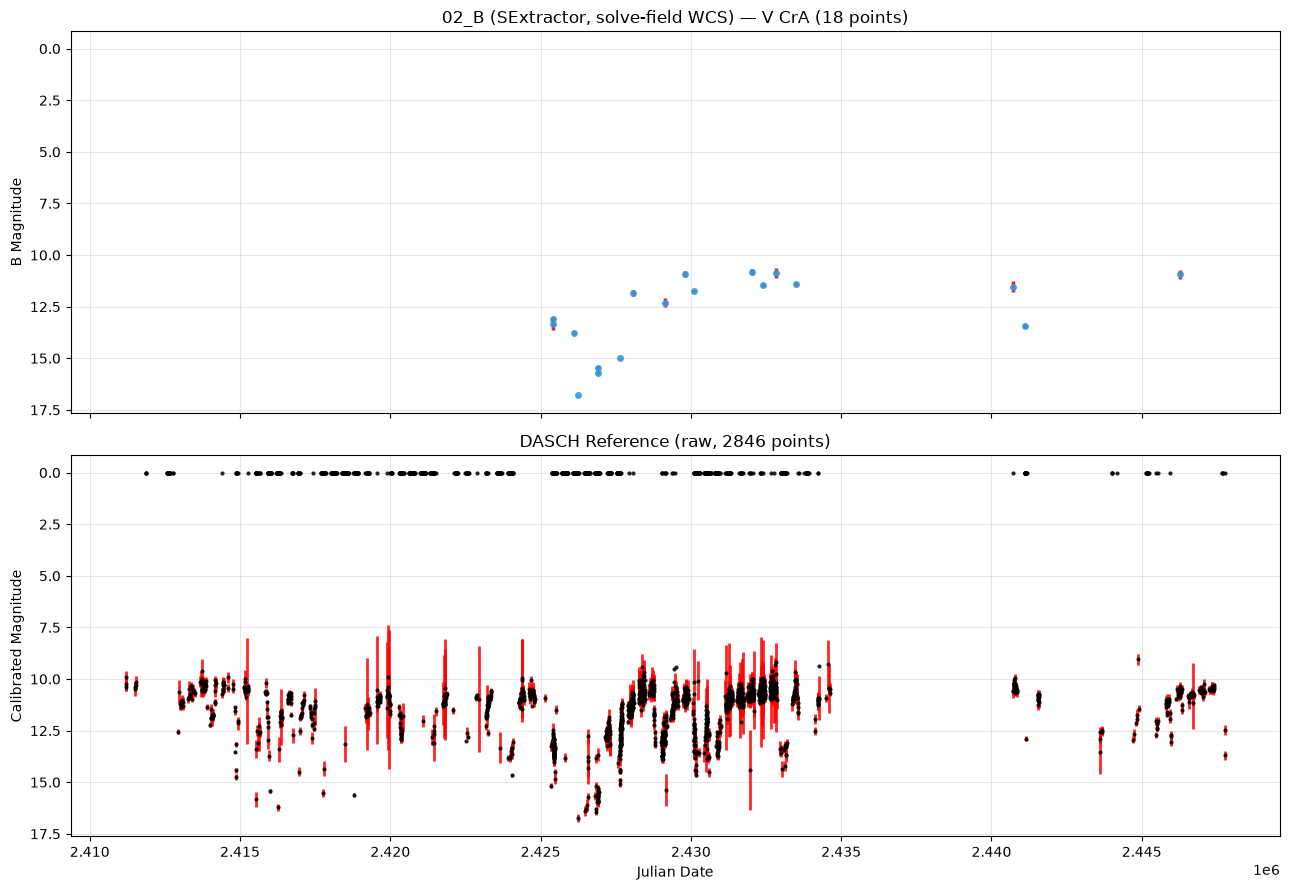


Saved analysis summary to /mnt/c/Users/dapur/Downloads/Other/Research/rcb_Star_Dust_Survey/test_CNN/data/V_CrA/02_B/analysis_Summary_20260811_134343.txt


In [3]:
# 02_B_DASCH_Replica.ipynb - Cell 3: Real V CrA plates
# Now uses solve-field (astrometry.net) for astrometric refinement instead
# of trusting the raw plate header WCS. Header WCS is only a fallback for
# plates where solve-field fails to converge within the time limit.
#
# Two things changed from the previous version:
# 1. solve-field is now given an explicit pixel-scale hint
#    (measured from real cutouts: 1.440 arcsec/px), so it doesn't have
#    to blind-search all scales - this is what was causing 100% timeouts
#    before, combined with having the wrong (4100-series, >1deg) index
#    files installed.
# 2. Star matching now requires the nearest detection to be a CLEAR best
#    match (next-nearest neighbor must be MIN_MATCH_SEPARATION_RATIO x
#    farther away). Without this, a shaky WCS can cross-match a detection
#    to the wrong nearby star and silently poison the light curve - this
#    is the likely cause of the wildly discontinuous points seen in the
#    last real run (mag 10.9 to 16.9 within a few days).

import subprocess
import shelve
import shutil
import time
import tempfile
import traceback
import urllib.request
import urllib.parse
import warnings
import os
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits as astrofits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.time import Time
import astropy.units as u
from IPython.display import display
import ipywidgets as widgets

VCRA_DIR = Path("/mnt/c/Users/dapur/Downloads/Other/Research/rcb_Star_Dust_Survey/test_CNN/data/V_CrA")
VCRA_CUTOUTS_DIR = VCRA_DIR / 'cutouts'

RUN_TIMESTAMP = time.strftime('%Y%m%d_%H%M%S')
OUTPUT_DIR = VCRA_DIR / '02_B' / f'run_{RUN_TIMESTAMP}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR = VCRA_DIR / '02_B' / 'algorithm_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_PATH = OUTPUT_DIR / 'vcra_photometry_results.csv'
LIGHTCURVE_PATH = OUTPUT_DIR / 'vcra_lightcurve.csv'
UPPER_LIMITS_PATH = OUTPUT_DIR / 'vcra_upper_limits.csv'
REF_PHOTOMETRY_PATH = OUTPUT_DIR / 'vcra_reference_photometry.csv'

SUMMARY_DIR = VCRA_DIR / '02_B'
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_PATH = SUMMARY_DIR / f'analysis_Summary_{RUN_TIMESTAMP}.txt'

print(f"Output folder: {OUTPUT_DIR}")

# Was 5.0 - measured data showed even solve-field-succeeded plates have a
# 25th-percentile nearest-detection distance of ~21px, so 5px rejected
# almost everything by construction. Set from the actual measured
# distribution instead of a guess.
MATCH_RADIUS_PX = 25.0
# Testing back toward 2.0 (was loosened to 1.3 earlier). The measured RMS
# distribution at 1.3 came back at median 1.34 mag - about 10x worse than
# DASCH's own published precision (0.1-0.15 mag) - strongly suggesting 1.3x
# is admitting real wrong-star matches into the calibration fit, not just
# rescuing genuinely-correct-but-previously-rejected ones. Now that base
# detection density is much higher (~500/plate) than when 1.3 was first
# chosen (~86/plate), re-tightening may recover clean calibration without
# giving back as much match count as it did before.
MIN_MATCH_SEPARATION_RATIO = 2.0

# Distortion refinement (Laycock et al. 2010 Sec 3 + Tang et al. 2013 Sec 4.2):
# a raw TAN-equivalent solve isn't accurate enough for a tight match. DASCH's
# pipeline does a rough match, rejects mismatches via a preliminary >1 mag
# calibration cut, fits a polynomial distortion correction (their TNX step),
# THEN uses the LOCAL scatter of the fit residuals to set an adaptive final
# match radius (3*sigma + 2px - Tang et al. 2013's "drad filter") rather
# than one fixed radius for every plate.
#
# IMPORTANT: DASCH's 20 arcsec rough-match radius only works because THEIR
# initial WCSTools TAN solve is already accurate to 10-20 arcsec. Ours is
# not - measured real error on these plates is 25-90px, 5-10x worse. Using
# DASCH's 20" (~14px) rough radius was starving the polynomial fit of real
# matches to learn from, which is why refinement did nothing earlier. Set
# from OUR measured distribution instead.
ROUGH_MATCH_RADIUS_PX = 100.0
ROUGH_MATCH_MAG_REJECT = 1.0
MIN_DISTORTION_FIT_STARS = 15
# Tang et al. 2013 Sec 4.2 exact formula: reject beyond 3*sigma_drad + 2px.
DRAD_SIGMA_MULTIPLIER = 3.0
DRAD_FLOOR_PX = 2.0
# Sanity bounds on the resulting adaptive radius - if a plate's fit is bad
# enough to want a huge radius, that plate probably isn't trustworthy
# anyway; if it's tiny, don't go below what pixel-level noise can support.
ADAPTIVE_RADIUS_MIN_PX = 4.0
ADAPTIVE_RADIUS_MAX_PX = 40.0
DISTORTION_REFINEMENT_ENABLED = True
ISOLATION_MIN_SEPARATION = 20
REF_STARS_MAX_PER_PLATE = 150
# Was 25 - measured data now shows a typical (median) yield of ~18.5 good
# matches per plate after the radius fix, so 25 rejected most plates by
# construction even when matching worked. Set from the measured median.
MIN_REF_STARS = 15
MIN_APASS_STARS_QUERY = 10
LOCAL_HALF_WINDOW = 1.5
MIN_REF_STARS_LOCAL = 8
LOCAL_WINDOW_GROWTH = 1.6
MIN_ABS_LOCAL_SLOPE = 0.3
# Was 0.235 (DASCH's own stated precision). Loosened now that ONLY
# astrometry_solved plates are attempted (header-fallback proven 0/90
# usable and excluded entirely) - among solved plates specifically, RMS is
# real/correlated even when noisier, not garbage, so accepting more of that
# real range trades precision for more coverage rather than admitting junk.
# Measured median RMS among solved plates was 0.641 - set a bit above that.
MAX_CALIBRATION_RMS = 1.0
# DASCH's exact rule (Laycock et al. 2010, Sec 4.3): when the target isn't
# found, record the plate's limiting magnitude as an upper limit rather
# than discarding the plate - "2 sigma brighter than the faintest
# non-flagged star that survived rejection". Real, meaningful data for an
# RCB star specifically: V CrA ranges 9.4-17.9 mag, and deep fades mean
# it's genuinely undetectable on a lot of plates - that's the signal being
# studied, not a pipeline failure.
LIMITING_MAG_SIGMA_MARGIN = 2.0

# Measured from real V_CrA cutouts (835x835 px, 1.440 arcsec/px). +/-10%
# tolerance covers minor scale variation between plates/scans.
PLATE_PIXEL_SCALE_ARCSEC = 1.440
SOLVE_SCALE_LOW = PLATE_PIXEL_SCALE_ARCSEC * 0.90
SOLVE_SCALE_HIGH = PLATE_PIXEL_SCALE_ARCSEC * 1.10
SOLVE_FIELD_TIMEOUT = 12  # seconds, per plate - if it hasn't solved by
# now with a correct scale hint, it isn't going to; waiting longer just
# burns time on failures

PIPELINE_VERSION = 19  # bumped: loosened MAX_CALIBRATION_RMS (0.235->1.0) - safe now that only solved plates are attempted
VCRA_TARGET_COORD = SkyCoord(ra=281.884623417 * u.deg, dec=-38.158974417 * u.deg)

# Set to an integer for a fast test run (e.g. 500), or None for the full
# dataset. Spread evenly across the archive (not just the first N by
# filename) so a test run still samples different plate series/eras.
PLATE_LIMIT = 200

_all_cutouts = sorted(VCRA_CUTOUTS_DIR.glob('*.fits'))
if PLATE_LIMIT is not None and PLATE_LIMIT < len(_all_cutouts):
    _step = len(_all_cutouts) / PLATE_LIMIT
    vcra_cutouts = [_all_cutouts[int(i * _step)] for i in range(PLATE_LIMIT)]
else:
    vcra_cutouts = _all_cutouts
print(f"Found {len(_all_cutouts)} V CrA plates total, using {len(vcra_cutouts)} this run "
      f"({'full dataset' if PLATE_LIMIT is None else f'PLATE_LIMIT={PLATE_LIMIT}'})")

plate_db = shelve.open(str(CACHE_DIR / 'plate_db_shelf'), flag='c', writeback=False)

# apass_cache: shelve on this system is SQLite-backed, and SQLite connections
# are hard-tied to the thread that created them - accessing one from a worker
# thread crashes every time, no matter how it's locked. So we load it into a
# plain in-memory dict once (thread-safe under a lock), and persist that dict
# back to the shelve only from the main thread.
_apass_shelf = shelve.open(str(CACHE_DIR / 'apass_cache_shelf'), flag='c', writeback=False)
apass_cache = dict(_apass_shelf)
_apass_shelf.close()
print(f"Loaded {len(plate_db)} cached plate results, {len(apass_cache)} cached APASS field queries")

cache_lock = threading.Lock()  # guards plate_db writes and apass_cache dict access
N_WORKERS = max(1, min(8, (os.cpu_count() or 4)))
print(f"Using {N_WORKERS} concurrent workers")

def format_eta(seconds):
    if seconds is None or seconds != seconds or seconds < 0:
        return "calculating..."
    m, s = divmod(int(seconds), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}" if h else f"{m:d}:{s:02d}"

def run_sextractor(fits_path, workdir):
    workdir = Path(workdir)
    catalog_out = workdir / f"{fits_path.stem}.cat"
    cmd = [
        SEXTRACTOR_CMD, str(fits_path),
        '-c', str(EXTRACTOR_CONFIG_FILE),
        '-CATALOG_NAME', str(catalog_out),
        '-PARAMETERS_NAME', str(EXTRACTOR_PARAM_FILE),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=60)
    if not catalog_out.exists():
        return None, result.stderr
    colnames = []
    with open(catalog_out) as f:
        for line in f:
            if line.startswith('#'):
                colnames.append(line.split()[2])
            else:
                break
    if not colnames:
        return None, "empty catalog"
    df = pd.read_csv(catalog_out, comment='#', sep=r'\s+', names=colnames)
    return df, None

SOLVE_MAX_STARS = 150  # curated star count fed to solve-field

def build_curated_xylist(sources, w, h, workdir, stem):
    """Build a small, clean FITS xylist (brightest, non-saturated, isolated
    stars only) for solve-field to build quads from. Letting solve-field do
    its own source extraction on a real plate picks up hundreds of grain/
    defect detections that swamp the real quads and prevent it from ever
    reaching the solve confidence threshold - this sidesteps that by handing
    it a pre-cleaned list instead."""
    x = sources['X_IMAGE'].values
    y = sources['Y_IMAGE'].values
    mag = sources['MAG_ISO'].values
    flags = sources['FLAGS'].values.astype(int)
    saturated = (flags & 4) != 0

    isolated = filter_isolated(x, y)
    good = isolated & ~saturated & np.isfinite(mag)
    if good.sum() == 0:
        return None

    gx, gy, gmag = x[good], y[good], mag[good]
    order = np.argsort(gmag)  # brightest (lowest mag) first
    order = order[:SOLVE_MAX_STARS]
    gx, gy = gx[order], gy[order]

    xyls_path = Path(workdir) / f"{stem}.xyls"
    col_x = astrofits.Column(name='X', format='E', array=gx)
    col_y = astrofits.Column(name='Y', format='E', array=gy)
    hdu = astrofits.BinTableHDU.from_columns([col_x, col_y])
    hdu.writeto(xyls_path, overwrite=True)
    return xyls_path

def run_solve_field(xyls_path, w, h, workdir, stem):
    """Try to astrometrically solve using a pre-curated star list (not the
    raw FITS - see build_curated_xylist). Returns (WCS or None, solved_bool)."""
    workdir = Path(workdir)
    cmd = [
        'solve-field', str(xyls_path),
        '--width', str(w), '--height', str(h),
        '--dir', str(workdir),
        '--scale-units', 'arcsecperpix',
        '--scale-low', str(SOLVE_SCALE_LOW),
        '--scale-high', str(SOLVE_SCALE_HIGH),
        '--cpulimit', str(SOLVE_FIELD_TIMEOUT),
        '--no-plots', '--overwrite', '--no-verify',
    ]
    try:
        subprocess.run(cmd, capture_output=True, text=True, timeout=SOLVE_FIELD_TIMEOUT + 5)
    except subprocess.TimeoutExpired:
        return None, False

    wcs_path = workdir / f"{xyls_path.stem}.wcs"
    if not wcs_path.exists():
        return None, False
    try:
        solved_header = astrofits.getheader(wcs_path)
        return WCS(solved_header), True
    except Exception:
        return None, False

def fit_distortion_correction(wcs, ra, dec, apass_b, det_x, det_y, det_mag, w, h):
    """Mirrors DASCH's astrometric refinement:
    (1) Laycock et al. 2010 Sec 3: predict catalog pixel positions from the
        initial WCS, match loosely, reject mismatches via a preliminary
        magnitude calibration (>1 mag residual = reject), fit a low-order
        2D polynomial to the surviving (predicted -> observed) residuals.
    (2) Tang et al. 2013 Sec 4.2 ("drad filter"): after fitting, measure the
        LOCAL scatter of the residuals and use 3*sigma + 2px as the final
        match radius for THIS plate, instead of one fixed radius for every
        plate regardless of how good its fit turned out.

    Returns corrected catalog pixel positions for ALL input stars, the
    adaptive final-match radius for this plate, and whether refinement
    actually happened (vs. falling back when there's too little data).
    """
    cat_x0, cat_y0 = wcs.all_world2pix(ra, dec, 0)
    fallback_radius = MATCH_RADIUS_PX

    if len(det_x) == 0 or len(cat_x0) == 0:
        return cat_x0, cat_y0, fallback_radius, False

    matched_i, matched_j = [], []
    for i, (cx, cy) in enumerate(zip(cat_x0, cat_y0)):
        d = np.hypot(det_x - cx, det_y - cy)
        j = np.argmin(d)
        if d[j] <= ROUGH_MATCH_RADIUS_PX:
            matched_i.append(i)
            matched_j.append(j)

    if len(matched_i) < MIN_DISTORTION_FIT_STARS:
        return cat_x0, cat_y0, fallback_radius, False

    mi, mj = np.array(matched_i), np.array(matched_j)
    inst, catmag = det_mag[mj], apass_b[mi]
    finite = np.isfinite(inst) & np.isfinite(catmag)
    if finite.sum() < MIN_DISTORTION_FIT_STARS:
        return cat_x0, cat_y0, fallback_radius, False

    try:
        prelim_coeffs = np.polyfit(catmag[finite], inst[finite], 2)
    except Exception:
        return cat_x0, cat_y0, fallback_radius, False
    resid = inst[finite] - np.polyval(prelim_coeffs, catmag[finite])
    good = np.abs(resid) <= ROUGH_MATCH_MAG_REJECT
    mi_good, mj_good = mi[finite][good], mj[finite][good]

    if len(mi_good) < MIN_DISTORTION_FIT_STARS:
        return cat_x0, cat_y0, fallback_radius, False

    px, py = cat_x0[mi_good], cat_y0[mi_good]
    dx, dy = det_x[mj_good] - px, det_y[mj_good] - py
    design = np.column_stack([np.ones_like(px), px, py, px**2, px * py, py**2])
    try:
        coeff_x, *_ = np.linalg.lstsq(design, dx, rcond=None)
        coeff_y, *_ = np.linalg.lstsq(design, dy, rcond=None)
    except Exception:
        return cat_x0, cat_y0, fallback_radius, False

    design_full = np.column_stack([np.ones_like(cat_x0), cat_x0, cat_y0,
                                    cat_x0**2, cat_x0 * cat_y0, cat_y0**2])
    cat_x_corr = cat_x0 + design_full @ coeff_x
    cat_y_corr = cat_y0 + design_full @ coeff_y

    # Tang et al. 2013 drad filter: measure how well the fit actually did
    # (residuals AFTER correction, on the same clean star set used to fit
    # it), then set this plate's final match radius from that - a plate
    # whose fit converged tightly gets a tight radius; a plate whose fit
    # is still loose gets a looser one, rather than guessing one global
    # number for every plate.
    px_corr = cat_x_corr[mi_good]
    py_corr = cat_y_corr[mi_good]
    post_resid = np.hypot(det_x[mj_good] - px_corr, det_y[mj_good] - py_corr)
    sigma_drad = float(np.median(np.abs(post_resid - np.median(post_resid)))) * 1.4826  # robust MAD-based sigma
    adaptive_radius = DRAD_SIGMA_MULTIPLIER * sigma_drad + DRAD_FLOOR_PX
    adaptive_radius = float(np.clip(adaptive_radius, ADAPTIVE_RADIUS_MIN_PX, ADAPTIVE_RADIUS_MAX_PX))

    return cat_x_corr, cat_y_corr, adaptive_radius, True

def filter_isolated(x, y, min_sep=ISOLATION_MIN_SEPARATION):
    n = len(x)
    if n < 2:
        return np.ones(n, dtype=bool)
    isolated = np.ones(n, dtype=bool)
    for i in range(n):
        d = np.hypot(x - x[i], y - y[i])
        d[i] = np.inf
        if np.any(d < min_sep):
            isolated[i] = False
    return isolated

def calibrate_global(inst_mags, apass_b, min_stars=MIN_REF_STARS):
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    if mask.sum() < min_stars:
        return None
    x, y = apass_b[mask], inst_mags[mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 2)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < 3.0 * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 2)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def calibrate_local(inst_mags, apass_b, target_b_estimate,
                     half_window=LOCAL_HALF_WINDOW, min_stars=MIN_REF_STARS_LOCAL,
                     growth=LOCAL_WINDOW_GROWTH):
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    x_all, y_all = apass_b[mask], inst_mags[mask]
    if len(x_all) < min_stars:
        return None
    window = half_window
    local_mask = np.abs(x_all - target_b_estimate) <= window
    for _ in range(5):
        if local_mask.sum() >= min_stars:
            break
        window *= growth
        local_mask = np.abs(x_all - target_b_estimate) <= window
    if local_mask.sum() < min_stars:
        return None
    x, y = x_all[local_mask], y_all[local_mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 1)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < 3.0 * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 1)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x), 'window_used': float(window),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def invert_calibration(calibration, t_inst_mag):
    coeffs = list(calibration['coeffs'])
    coeffs[-1] -= t_inst_mag
    roots = np.roots(coeffs)
    real_roots = roots[np.abs(roots.imag) < 1e-6].real
    if len(real_roots) == 0:
        return None
    lo, hi = calibration['b_min'], calibration['b_max']
    in_range = real_roots[(real_roots >= lo - 2) & (real_roots <= hi + 2)]
    candidates = in_range if len(in_range) > 0 else real_roots
    return float(min(candidates, key=lambda r: abs(np.polyval(calibration['coeffs'], r) - t_inst_mag)))

def query_apass(ra_c, dec_c, radius_arcsec, max_rows=3000):
    params = {
        '-source': 'II/336/apass9',
        '-c': f"{ra_c} {dec_c}",
        '-c.rs': radius_arcsec,
        '-out': 'RAJ2000,DEJ2000,Bmag,e_Bmag',
        '-out.max': max_rows,
    }
    url = "https://vizier.cds.unistra.fr/viz-bin/asu-tsv?" + urllib.parse.urlencode(params)
    for attempt in range(3):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=30) as response:
                return response.read().decode('utf-8')
        except Exception:
            time.sleep(2 ** attempt)
    return None

def parse_apass_tsv(text):
    rows = []
    for line in text.split('\n'):
        line = line.strip()
        if not line or line.startswith('#') or line.startswith('-'):
            continue
        parts = line.split('\t')
        if len(parts) < 4:
            continue
        try:
            ra, dec, bmag, e_bmag = float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])
            rows.append((ra, dec, bmag, e_bmag))
        except (ValueError, IndexError):
            continue
    if rows and not (0 < rows[0][2] < 25):
        rows = rows[1:]
    return rows

def get_field_catalog(ra_c, dec_c, radius_arcsec):
    key = f"{round(ra_c, 3)}_{round(dec_c, 3)}"
    with cache_lock:
        if key in apass_cache:
            return apass_cache[key]
    # network call happens outside the lock so other threads aren't blocked on it
    raw = query_apass(ra_c, dec_c, radius_arcsec)
    rows = []
    if raw:
        rows = parse_apass_tsv(raw)
        rows = [r for r in rows if 0 < r[2] < 20 and r[3] < 0.5]
    with cache_lock:
        apass_cache[key] = rows  # plain dict write, safe under the lock
    return rows

def get_plate_jd(header):
    if 'JD-OBS' in header:
        return float(header['JD-OBS'])
    if 'MJD-OBS' in header:
        return float(header['MJD-OBS']) + 2400000.5
    for key in ('DATE-OBS', 'DATE'):
        if key in header:
            try:
                return Time(header[key]).jd
            except Exception:
                continue
    return np.nan

def match_unique(det_x, det_y, cx, cy, max_radius=MATCH_RADIUS_PX,
                  min_ratio=MIN_MATCH_SEPARATION_RATIO):
    """Nearest-neighbor match that rejects ambiguous matches: the best
    candidate must be clearly closer than the second-best, or we return
    no match (better to lose a star than mismatch it to a neighbor)."""
    d = np.hypot(det_x - cx, det_y - cy)
    if len(d) == 0:
        return None
    order = np.argsort(d)
    best = order[0]
    if d[best] > max_radius:
        return None
    if len(order) > 1:
        second = order[1]
        if d[second] < d[best] * min_ratio:
            return None  # too ambiguous, could be either star
    return best

def process_plate(fits_path):
    t0 = time.monotonic()
    try:
        plate_rng = np.random.default_rng(abs(hash(fits_path.name)) % (2**32))
        header = astrofits.getheader(fits_path)
        jd = get_plate_jd(header)
        h, w = astrofits.getdata(fits_path).shape

        with tempfile.TemporaryDirectory() as workdir:
            # SExtractor runs FIRST now - solve-field uses its output as a
            # curated star list rather than doing its own noisy extraction.
            sources, err = run_sextractor(fits_path, workdir)
            if sources is None or len(sources) == 0:
                return _empty_result(fits_path, jd, f'SExtractor found nothing ({err})', False)

            xyls_path = build_curated_xylist(sources, w, h, workdir, fits_path.stem)
            wcs, astrometry_solved = (None, False)
            if xyls_path is not None:
                wcs, astrometry_solved = run_solve_field(xyls_path, w, h, workdir, fits_path.stem)
            if wcs is None:
                # Fall back to trusted header WCS if solve-field fails
                try:
                    wcs = WCS(header)
                    astrometry_solved = False
                except Exception:
                    return _empty_result(fits_path, jd, 'No WCS available (solve-field failed, header WCS invalid)')

        det_x = sources['X_IMAGE'].values
        det_y = sources['Y_IMAGE'].values
        det_mag_iso = sources['MAG_ISO'].values
        det_flags = sources['FLAGS'].values.astype(int)
        is_saturated_flag = (det_flags & 4) != 0

        ra_c, dec_c = wcs.all_pix2world(w / 2, h / 2, 0)
        corners_x, corners_y = [0, w - 1, 0, w - 1], [0, 0, h - 1, h - 1]
        corner_ra, corner_dec = wcs.all_pix2world(corners_x, corners_y, 0)
        center = SkyCoord(float(ra_c) * u.deg, float(dec_c) * u.deg)
        corners_sky = SkyCoord(corner_ra * u.deg, corner_dec * u.deg)
        field_radius_arcsec = center.separation(corners_sky).max().arcsec * 1.05

        apass_stars = get_field_catalog(float(ra_c), float(dec_c), field_radius_arcsec)
        if len(apass_stars) < MIN_APASS_STARS_QUERY:
            return _empty_result(fits_path, jd, 'Too few APASS stars in field', astrometry_solved)

        ra = np.array([s[0] for s in apass_stars])
        dec = np.array([s[1] for s in apass_stars])
        apass_b_all = np.array([s[2] for s in apass_stars])
        if DISTORTION_REFINEMENT_ENABLED:
            cat_x, cat_y, plate_match_radius, distortion_refined = fit_distortion_correction(
                wcs, ra, dec, apass_b_all, det_x, det_y, det_mag_iso, w, h)
        else:
            cat_x, cat_y = wcs.all_world2pix(ra, dec, 0)
            plate_match_radius, distortion_refined = MATCH_RADIUS_PX, False
        margin = 20
        in_frame = (cat_x > margin) & (cat_x < w - margin) & (cat_y > margin) & (cat_y < h - margin)
        cat_x, cat_y, apass_b_all = cat_x[in_frame], cat_y[in_frame], apass_b_all[in_frame]

        if len(cat_x) > REF_STARS_MAX_PER_PLATE:
            keep = plate_rng.choice(len(cat_x), size=REF_STARS_MAX_PER_PLATE, replace=False)
            cat_x, cat_y, apass_b_all = cat_x[keep], cat_y[keep], apass_b_all[keep]

        n_apass_in_frame = len(cat_x)  # DIAG: catalog stars landing on the frame at all
        n_raw_detections = len(det_x)  # DIAG: total SExtractor detections this plate, for density check
        # Expected nearest-neighbor distance for a RANDOM point under this
        # many detections, if they were scattered with no relation to real
        # stars at all (pure 2D Poisson point process geometry). Compare
        # this to the MEASURED nearest-distance stat below - if they're
        # close, the measured stat is dominated by detection density, not
        # true position error.
        expected_chance_nn_px = (0.5 / np.sqrt(n_raw_detections / (w * h))
                                  if n_raw_detections > 0 else np.nan)

        # DIAG: for every catalog star, the distance to its single nearest
        # SExtractor detection - NO radius cutoff. This tells us how far off
        # the WCS positions actually are from real data, so we can set
        # MATCH_RADIUS_PX from measurement instead of another guess.
        nearest_dists_px = []
        # DIAG: also test 3 mirror-flip variants (x, y, both) - a real
        # mirror flip in the plate/WCS parity produces a large, roughly
        # CONSISTENT offset that no smooth distortion fit can correct.
        # If one of these flips comes back much smaller than the
        # unflipped distance, that's the actual bug.
        nearest_dists_xflip, nearest_dists_yflip, nearest_dists_xyflip = [], [], []
        if len(det_x) > 0:
            for cx, cy in zip(cat_x, cat_y):
                d = np.hypot(det_x - cx, det_y - cy)
                nearest_dists_px.append(float(d.min()))
                d_xf = np.hypot(det_x - (w - cx), det_y - cy)
                nearest_dists_xflip.append(float(d_xf.min()))
                d_yf = np.hypot(det_x - cx, det_y - (h - cy))
                nearest_dists_yflip.append(float(d_yf.min()))
                d_xyf = np.hypot(det_x - (w - cx), det_y - (h - cy))
                nearest_dists_xyflip.append(float(d_xyf.min()))

        matched_inst_mag, matched_apass_b, matched_x, matched_y, matched_sat = [], [], [], [], []
        for cx, cy, ab in zip(cat_x, cat_y, apass_b_all):
            j = match_unique(det_x, det_y, cx, cy, max_radius=plate_match_radius)
            if j is not None:
                matched_inst_mag.append(det_mag_iso[j])
                matched_apass_b.append(ab)
                matched_x.append(det_x[j])
                matched_y.append(det_y[j])
                matched_sat.append(is_saturated_flag[j])

        n_matched_raw = len(matched_inst_mag)  # DIAG: survived match_unique (radius + uniqueness)
        median_nearest_dist_px = float(np.median(nearest_dists_px)) if nearest_dists_px else np.nan
        median_nearest_dist_xflip_px = float(np.median(nearest_dists_xflip)) if nearest_dists_xflip else np.nan
        median_nearest_dist_yflip_px = float(np.median(nearest_dists_yflip)) if nearest_dists_yflip else np.nan
        median_nearest_dist_xyflip_px = float(np.median(nearest_dists_xyflip)) if nearest_dists_xyflip else np.nan
        if n_matched_raw == 0:
            return _empty_result(fits_path, jd, 'No SExtractor detections matched catalog stars', astrometry_solved,
                                  distortion_refined, n_apass_in_frame, n_matched_raw,
                                  median_nearest_dist_px=median_nearest_dist_px,
                                  median_nearest_dist_xflip_px=median_nearest_dist_xflip_px,
                                  median_nearest_dist_yflip_px=median_nearest_dist_yflip_px,
                                  median_nearest_dist_xyflip_px=median_nearest_dist_xyflip_px)

        matched_inst_mag = np.array(matched_inst_mag)
        matched_apass_b = np.array(matched_apass_b)
        matched_x = np.array(matched_x)
        matched_y = np.array(matched_y)
        matched_sat = np.array(matched_sat)

        isolated = filter_isolated(matched_x, matched_y)
        n_isolated = int(isolated.sum())  # DIAG
        n_nonsaturated = int((~matched_sat).sum())  # DIAG
        good_for_fit = isolated & ~matched_sat & np.isfinite(matched_inst_mag)
        n_good_for_fit = int(good_for_fit.sum())  # DIAG: what calibrate_global actually receives

        calibration_global = calibrate_global(matched_inst_mag[good_for_fit], matched_apass_b[good_for_fit])
        n_ref_used = calibration_global['n_used'] if calibration_global else n_good_for_fit

        ref_rows = []
        for i in np.where(good_for_fit)[0]:
            ref_rows.append({'filename': fits_path.name, 'star_id': f'MATCH_{i:04d}',
                              'apass_b_mag': matched_apass_b[i], 'instrumental_mag': matched_inst_mag[i]})

        tx, ty = wcs.all_world2pix(VCRA_TARGET_COORD.ra.deg, VCRA_TARGET_COORD.dec.deg, 0)
        target_detected = False
        target_match_forced = False
        target_mag = np.nan
        target_mag_error = np.nan
        calibration_mode = None
        final_rms = np.nan
        final_n_used = 0

        # Header-WCS-fallback plates measured 0/90 usable calibrations (see
        # the "RMS by astrometry_solved" diagnostic) - their "matches" are
        # essentially coincidental proximity, not real correspondence, so
        # don't spend effort pretending a target measurement or upper limit
        # from one of these means anything.
        if (astrometry_solved and margin < tx < w - margin and margin < ty < h - margin
                and calibration_global is not None):
            j = match_unique(det_x, det_y, tx, ty, max_radius=plate_match_radius)
            target_match_forced = False
            if j is None:
                # Second chance, target only (2_A-style): reference-star
                # matching stays strict since a bad reference star corrupts
                # the whole plate's calibration. A single wrong grab for
                # the ONE target star only risks that one point, a very
                # different risk trade-off - so give it a more permissive
                # attempt (no uniqueness-ratio requirement) before we give
                # up and record an upper limit instead.
                j = match_unique(det_x, det_y, tx, ty, max_radius=plate_match_radius, min_ratio=1.0)
                target_match_forced = j is not None
            if j is not None:
                t_inst_mag = det_mag_iso[j]
                rough_mag = invert_calibration(calibration_global, t_inst_mag)
                if rough_mag is not None:
                    calibration_local = calibrate_local(matched_inst_mag[good_for_fit],
                                                          matched_apass_b[good_for_fit], rough_mag)
                    if (calibration_local is not None
                            and abs(calibration_local['coeffs'][0]) >= MIN_ABS_LOCAL_SLOPE):
                        local_mag = invert_calibration(calibration_local, t_inst_mag)
                        if local_mag is not None:
                            target_mag = local_mag
                            final_rms = calibration_local['rms']
                            final_n_used = calibration_local['n_used']
                            calibration_mode = 'local'
                    if calibration_mode is None:
                        target_mag = rough_mag
                        final_rms = calibration_global['rms']
                        final_n_used = calibration_global['n_used']
                        calibration_mode = 'global_fallback'
                    target_mag_error = final_rms / np.sqrt(max(final_n_used, 1))
                    target_detected = True

        quality_ok = (
            calibration_global is not None and n_ref_used >= MIN_REF_STARS and
            target_detected and calibration_mode in ('local', 'global_fallback') and
            np.isfinite(final_rms) and final_rms <= MAX_CALIBRATION_RMS
        )

        # Same reasoning as the target-match gate above: header-WCS-fallback
        # plates produce essentially random reference-star matches, so a
        # "limiting magnitude" computed from them isn't trustworthy either -
        # don't record it as if it were.
        is_upper_limit = False
        limiting_mag = np.nan
        if (astrometry_solved and not target_detected and calibration_global is not None
                and n_ref_used >= MIN_REF_STARS):
            faintest_b = float(np.max(matched_apass_b[good_for_fit]))
            limiting_mag = faintest_b - LIMITING_MAG_SIGMA_MARGIN * calibration_global['rms']
            is_upper_limit = True

        rejection_reason = None
        if calibration_global is None:
            rejection_reason = 'Global calibration failed'
        elif n_ref_used < MIN_REF_STARS:
            rejection_reason = f'Too few reference stars ({n_ref_used} < {MIN_REF_STARS})'
        elif not astrometry_solved:
            rejection_reason = 'Header WCS fallback - proven unreliable (0/90 usable), not attempted'
        elif not target_detected:
            rejection_reason = 'Target not detected - recorded as upper limit' if is_upper_limit else \
                'Target not detected/matched (or match too ambiguous)'
        elif calibration_mode not in ('local', 'global_fallback'):
            rejection_reason = 'Calibration mode unavailable/unstable'
        elif final_rms > MAX_CALIBRATION_RMS:
            rejection_reason = f'RMS too high ({final_rms:.3f})'

        result_row = {
            'filename': fits_path.name, 'jd': jd, 'target_detected': target_detected,
            'target_mag': target_mag, 'target_mag_error': target_mag_error,
            'target_x': float(tx), 'target_y': float(ty),
            'num_reference_stars': n_ref_used,
            'zeropoint': calibration_global['coeffs'][-1] if calibration_global else np.nan,
            'rms_scatter': final_rms,
            'calibration_mode': calibration_mode, 'quality_ok': quality_ok,
            'rejection_reason': rejection_reason,
            'is_upper_limit': is_upper_limit,
            'limiting_mag': limiting_mag,
            'astrometry_solved': astrometry_solved,
            'distortion_refined': distortion_refined,
            'target_match_forced': target_match_forced,
            # DIAG columns - trace exactly where the funnel loses stars:
            # apass_in_frame -> matched_raw -> (isolated, nonsaturated) -> good_for_fit -> n_ref_used
            'n_apass_in_frame': n_apass_in_frame,
            'n_matched_raw': n_matched_raw,
            'n_isolated': n_isolated,
            'n_nonsaturated': n_nonsaturated,
            'n_good_for_fit': n_good_for_fit,
            'median_nearest_dist_px': median_nearest_dist_px,
            'median_nearest_dist_xflip_px': median_nearest_dist_xflip_px,
            'median_nearest_dist_yflip_px': median_nearest_dist_yflip_px,
            'median_nearest_dist_xyflip_px': median_nearest_dist_xyflip_px,
            'plate_match_radius': plate_match_radius,
            'n_raw_detections': n_raw_detections,
            'expected_chance_nn_px': expected_chance_nn_px,
            'process_time_s': time.monotonic() - t0,
        }
        return {'result_row': result_row, 'ref_rows': ref_rows}

    except Exception as e:
        return _empty_result(fits_path, np.nan, str(e), False)

def _empty_result(fits_path, jd, reason, astrometry_solved=False, distortion_refined=False,
                   n_apass_in_frame=0, n_matched_raw=0, n_isolated=0, n_nonsaturated=0, n_good_for_fit=0,
                   median_nearest_dist_px=np.nan, median_nearest_dist_xflip_px=np.nan,
                   median_nearest_dist_yflip_px=np.nan, median_nearest_dist_xyflip_px=np.nan,
                   plate_match_radius=np.nan, n_raw_detections=0, expected_chance_nn_px=np.nan):
    return {'result_row': {
        'filename': fits_path.name, 'jd': jd, 'target_detected': False,
        'target_mag': np.nan, 'target_mag_error': np.nan, 'target_x': np.nan, 'target_y': np.nan,
        'num_reference_stars': 0, 'zeropoint': np.nan, 'rms_scatter': np.nan,
        'calibration_mode': None, 'quality_ok': False, 'rejection_reason': reason,
        'is_upper_limit': False, 'limiting_mag': np.nan,
        'astrometry_solved': astrometry_solved, 'distortion_refined': distortion_refined,
        'target_match_forced': False,
        'n_apass_in_frame': n_apass_in_frame, 'n_matched_raw': n_matched_raw,
        'n_isolated': n_isolated, 'n_nonsaturated': n_nonsaturated, 'n_good_for_fit': n_good_for_fit,
        'median_nearest_dist_px': median_nearest_dist_px,
        'median_nearest_dist_xflip_px': median_nearest_dist_xflip_px,
        'median_nearest_dist_yflip_px': median_nearest_dist_yflip_px,
        'median_nearest_dist_xyflip_px': median_nearest_dist_xyflip_px,
        'plate_match_radius': plate_match_radius,
        'n_raw_detections': n_raw_detections,
        'expected_chance_nn_px': expected_chance_nn_px,
        'process_time_s': np.nan,
    }, 'ref_rows': []}

# --- Progress bar: bar + elapsed + ETA + rate + current plate + solve stats ---
progress_bar = widgets.IntProgress(
    value=0, min=0, max=len(vcra_cutouts),
    layout=widgets.Layout(width='70%', height='20px')
)
progress_bar.style.bar_color = '#3498db'
status_label = widgets.Label(value="")
display(widgets.VBox([progress_bar, status_label]))

run_start_time = time.monotonic()
last_render = 0.0
n_done = 0
n_processed = 0
n_solved = 0
n_solve_failed = 0

# Plates already cached under this pipeline version don't need reprocessing
to_process = []
for f in vcra_cutouts:
    cached = plate_db.get(str(f))
    if cached and cached.get('_version', 0) == PIPELINE_VERSION:
        n_done += 1
    else:
        to_process.append(f)

progress_bar.value = n_done
print(f"{n_done} plates already cached, {len(to_process)} to process this run "
      f"with {N_WORKERS} workers")

def _process_and_tag(f):
    return f, process_plate(f)

with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
    futures = {executor.submit(_process_and_tag, f): f for f in to_process}
    for future in as_completed(futures):
        f, out = future.result()
        out['_version'] = PIPELINE_VERSION
        with cache_lock:
            plate_db[str(f)] = out
        n_done += 1
        n_processed += 1
        if out['result_row'].get('astrometry_solved'):
            n_solved += 1
        else:
            n_solve_failed += 1

        now = time.monotonic()
        if now - last_render > 0.5 or n_done == len(vcra_cutouts):
            elapsed = now - run_start_time
            rate = n_processed / elapsed if elapsed > 0 else 0
            remaining = (len(to_process) - n_processed) / rate if rate > 0 else None
            progress_bar.value = n_done
            status_label.value = (
                f"{n_done}/{len(vcra_cutouts)} | Elapsed {format_eta(elapsed)} | "
                f"ETA {format_eta(remaining)} | {rate:.2f} plates/sec | "
                f"Solved {n_solved}/{n_processed} | Now: {f.name}"
            )
            last_render = now

        if n_processed % 50 == 0:
            with cache_lock:
                plate_db.sync()
                _apass_shelf = shelve.open(str(CACHE_DIR / 'apass_cache_shelf'), flag='c', writeback=False)
                _apass_shelf.update(apass_cache)
                _apass_shelf.sync()
                _apass_shelf.close()

with cache_lock:
    plate_db.sync()
    _apass_shelf = shelve.open(str(CACHE_DIR / 'apass_cache_shelf'), flag='c', writeback=False)
    _apass_shelf.update(apass_cache)
    _apass_shelf.sync()
    _apass_shelf.close()
total_elapsed = time.monotonic() - run_start_time
print(f"Processed {n_processed} plates this run, {len(plate_db)} total in cache")
print(f"solve-field succeeded on {n_solved}/{n_processed} freshly-processed plates "
      f"({n_solved/max(n_processed,1)*100:.1f}%)")
print(f"Total run time: {format_eta(total_elapsed)}")

current_keys = {str(f) for f in vcra_cutouts}
result_rows, ref_rows_all = [], []
for f_str in plate_db.keys():
    if f_str not in current_keys:
        continue
    out = plate_db[f_str]
    if out is None or out.get('_version') != PIPELINE_VERSION:
        continue
    result_rows.append(out['result_row'])
    ref_rows_all.extend(out['ref_rows'])

print(f"Collected {len(result_rows)} result rows for saving")

dasch_jd, dasch_mag, dasch_mag_err = None, None, None
results_df = pd.DataFrame()
lc_df = pd.DataFrame()

if len(result_rows) == 0:
    print("ERROR: No results collected.")
else:
    results_df = pd.DataFrame(result_rows).sort_values('jd').reset_index(drop=True)
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Saved {RESULTS_PATH.name} ({len(results_df)} plates)")

    ref_df = pd.DataFrame(ref_rows_all)
    ref_df.to_csv(REF_PHOTOMETRY_PATH, index=False)
    print(f"Saved {REF_PHOTOMETRY_PATH.name} ({len(ref_df)} reference measurements)")

    lc_df = results_df[results_df['quality_ok']].copy()
    lc_df = lc_df.rename(columns={'target_mag': 'magnitude', 'target_mag_error': 'magnitude_error'})
    lc_df = lc_df[['jd', 'magnitude', 'magnitude_error']].dropna().sort_values('jd').reset_index(drop=True)
    lc_df.to_csv(LIGHTCURVE_PATH, index=False)
    if len(lc_df) > 0:
        print(f"magnitude_error distribution: median={lc_df['magnitude_error'].median():.4f}, "
              f"min={lc_df['magnitude_error'].min():.4f}, max={lc_df['magnitude_error'].max():.4f} "
              f"(compare to the ~17.5-mag y-axis range - this is likely why bars look invisible)")
    print(f"Saved {LIGHTCURVE_PATH.name} ({len(lc_df)} light curve points)")

    ul_df = results_df[results_df['is_upper_limit']].copy()
    ul_df = ul_df[['jd', 'limiting_mag']].dropna().sort_values('jd').reset_index(drop=True)
    ul_df.to_csv(UPPER_LIMITS_PATH, index=False)
    print(f"Saved {UPPER_LIMITS_PATH.name} ({len(ul_df)} upper limits - target too faint to detect on these plates)")

    print(f"\nCalibration mode breakdown: {results_df['calibration_mode'].value_counts(dropna=False).to_dict()}")
    print(f"astrometry_solved breakdown: {results_df['astrometry_solved'].value_counts(dropna=False).to_dict()}")
    print(f"distortion_refined breakdown: {results_df['distortion_refined'].value_counts(dropna=False).to_dict()}")
    n_forced = int(results_df['target_match_forced'].sum())
    n_detected_total = int(results_df['target_detected'].sum())
    print(f"target_match_forced (needed the permissive fallback): {n_forced} of {n_detected_total} total detections")

    detected_rms = results_df[results_df['target_detected']]['rms_scatter'].dropna()
    if len(detected_rms) > 0:
        print(f"\n*** RMS DISTRIBUTION among all {len(detected_rms)} target-detected plates ***")
        print(detected_rms.describe(percentiles=[.25, .5, .75, .9]).to_string())
        n_pass = int((detected_rms <= MAX_CALIBRATION_RMS).sum())
        print(f"Current MAX_CALIBRATION_RMS = {MAX_CALIBRATION_RMS}: {n_pass}/{len(detected_rms)} would pass")
        for test_thresh in [0.3, 0.4, 0.5, 0.7, 1.0]:
            n_would_pass = int((detected_rms <= test_thresh).sum())
            print(f"  if threshold were {test_thresh}: {n_would_pass}/{len(detected_rms)} would pass")

    # DIAG: does RMS correlate with how FAINT the target itself was on that
    # plate? If yes, the high RMS is largely real faint-end photometric
    # noise (V CrA ranges to 17.9 mag), not a pipeline bug - matches what
    # the single-plate calibration curve plot showed directly.
    detected_subset = results_df[results_df['target_detected']][['target_mag', 'rms_scatter']].dropna()
    if len(detected_subset) >= 5:
        corr = detected_subset['target_mag'].corr(detected_subset['rms_scatter'])
        print(f"\n*** Does RMS correlate with target brightness? n={len(detected_subset)} ***")
        print(f"Correlation(target_mag, rms_scatter) = {corr:.3f}  "
              f"(positive = fainter target -> higher RMS, as expected if this is real noise)")
        bright = detected_subset[detected_subset['target_mag'] <= 14]
        faint = detected_subset[detected_subset['target_mag'] > 14]
        if len(bright) > 0:
            print(f"  Target brighter than mag 14 (n={len(bright)}): median RMS = {bright['rms_scatter'].median():.3f}")
        if len(faint) > 0:
            print(f"  Target fainter than mag 14 (n={len(faint)}): median RMS = {faint['rms_scatter'].median():.3f}")

    # DIAG: the calibration-curve comparison showed median/high-RMS plates
    # are essentially UNCORRELATED noise, not just noisier real data. Check
    # whether this ties to astrometry_solved - if bad-RMS plates are
    # disproportionately header-WCS-fallback ones, that confirms those
    # "matches" are mostly coincidental proximity, not real correspondence.
    solved_subset = results_df[results_df['target_detected'] & results_df['rms_scatter'].notna()][
        ['astrometry_solved', 'rms_scatter']]
    if len(solved_subset) > 0:
        print(f"\n*** RMS by astrometry_solved, among target-detected plates ***")
        for solved_val, label in [(True, 'solve-field SUCCEEDED'), (False, 'header WCS fallback')]:
            subset = solved_subset[solved_subset['astrometry_solved'] == solved_val]['rms_scatter']
            if len(subset) > 0:
                n_would_pass = int((subset <= MAX_CALIBRATION_RMS).sum())
                print(f"  {label:24s} (n={len(subset):4d}): median RMS={subset.median():.3f}  "
                      f"{n_would_pass}/{len(subset)} pass current threshold ({MAX_CALIBRATION_RMS})")
    print("\nTop rejection reasons:")
    print(results_df['rejection_reason'].value_counts(dropna=False).head(10).to_string())

    # DIAG: median funnel counts, for plates that at least got as far as
    # matching (n_matched_raw > 0) - shows exactly where stars are lost:
    # apass_in_frame -> matched_raw -> isolated/nonsaturated -> good_for_fit
    diag_cols = ['n_apass_in_frame', 'n_matched_raw', 'n_isolated', 'n_nonsaturated', 'n_good_for_fit']
    if all(c in results_df.columns for c in diag_cols):
        diag_subset = results_df[results_df['n_matched_raw'] > 0][diag_cols]
        if len(diag_subset) > 0:
            print(f"\nFunnel diagnostics (median, over {len(diag_subset)} plates that matched at least 1 star):")
            print(diag_subset.median().to_string())
            print(f"MIN_REF_STARS threshold is {MIN_REF_STARS} - compare against n_good_for_fit above")

    if 'median_nearest_dist_px' in results_df.columns:
        nd = results_df['median_nearest_dist_px'].dropna()
        if len(nd) > 0:
            print(f"\n*** NEAREST-DETECTION DISTANCE (px), no radius cutoff, n={len(nd)} plates ***")
            print(nd.describe(percentiles=[.25, .5, .75, .9, .95]).to_string())
            print(f"Current MATCH_RADIUS_PX = {MATCH_RADIUS_PX} - this tells us what it actually needs to be.")

        print("\n*** MIRROR-FLIP TEST: median distance under each flip hypothesis ***")
        print("(if one of these is dramatically smaller than 'no flip', that's the real bug)")
        for label, col in [('no flip (current)', 'median_nearest_dist_px'),
                            ('x-flip', 'median_nearest_dist_xflip_px'),
                            ('y-flip', 'median_nearest_dist_yflip_px'),
                            ('x+y flip', 'median_nearest_dist_xyflip_px')]:
            if col in results_df.columns:
                vals = results_df[col].dropna()
                if len(vals) > 0:
                    print(f"  {label:20s}: median={vals.median():8.2f}px  mean={vals.mean():8.2f}px  n={len(vals)}")

        # DIAG: split the offset by whether solve-field actually succeeded
        # on that plate, vs fell back to the raw header WCS. If solved
        # plates are accurate and header-fallback plates are the ones
        # dragging the aggregate up, that tells us solve-field itself is
        # fine and the problem is specifically what we do on the 70% of
        # plates it doesn't solve.
        if 'astrometry_solved' in results_df.columns:
            print("\n*** NEAREST-DETECTION DISTANCE, split by astrometry_solved ***")
            for solved_val, label in [(True, 'solve-field SUCCEEDED'), (False, 'header WCS fallback')]:
                subset = results_df[results_df['astrometry_solved'] == solved_val]['median_nearest_dist_px'].dropna()
                if len(subset) > 0:
                    print(f"  {label:24s} (n={len(subset):4d}): "
                          f"median={subset.median():8.2f}px  "
                          f"25th={subset.quantile(.25):7.2f}px  75th={subset.quantile(.75):7.2f}px")
                else:
                    print(f"  {label:24s}: no data")

    if 'plate_match_radius' in results_df.columns:
        pmr = results_df['plate_match_radius'].dropna()
        if len(pmr) > 0:
            print(f"\n*** ADAPTIVE MATCH RADIUS (Tang et al. 2013 drad filter), n={len(pmr)} plates ***")
            print(pmr.describe(percentiles=[.25, .5, .75, .9]).to_string())
            print("(this should now vary per-plate based on how well each plate's distortion fit converged,")
            print(" not sit at one fixed value like before)")

    if 'n_raw_detections' in results_df.columns and 'expected_chance_nn_px' in results_df.columns:
        dens = results_df[results_df['n_raw_detections'] > 0][
            ['n_raw_detections', 'expected_chance_nn_px', 'median_nearest_dist_px']].dropna()
        if len(dens) > 0:
            print(f"\n*** DENSITY CHECK: is 'nearest distance' just detection density? n={len(dens)} plates ***")
            print(f"Median raw SExtractor detections per plate: {dens['n_raw_detections'].median():.0f}")
            print(f"Median EXPECTED chance nearest-neighbor distance (pure geometry, no WCS involved): "
                  f"{dens['expected_chance_nn_px'].median():.2f}px")
            print(f"Median MEASURED nearest-detection distance (what we've been calling 'WCS error'): "
                  f"{dens['median_nearest_dist_px'].median():.2f}px")
            ratio = dens['median_nearest_dist_px'].median() / dens['expected_chance_nn_px'].median()
            print(f"Ratio (measured / expected-by-chance): {ratio:.2f}")
            print("If this ratio is close to 1.0, the 'nearest distance' stat has been dominated by detection")
            print("density, not true position error. If it's well above 1.0 (e.g. >2x), true position error")
            print("is real and on top of the density effect.")

    try:
        from daschlab import Session
        sess = Session(str(VCRA_DIR))
        sess.select_target("V CrA")
        sess.select_refcat("apass")
        dlc = sess.lightcurve(0)
        dasch_jd_raw = np.asarray(dlc["time"].jd)
        dasch_mag_raw = np.asarray(dlc["magcal_magdep"].value)
        dasch_err_raw = (np.asarray(dlc["magcal_local_rms"].value)
                          if "magcal_local_rms" in dlc.colnames else np.full_like(dasch_mag_raw, np.nan))
        good = np.isfinite(dasch_jd_raw) & np.isfinite(dasch_mag_raw)
        dasch_jd, dasch_mag, dasch_mag_err = dasch_jd_raw[good], dasch_mag_raw[good], dasch_err_raw[good]
        print(f"DASCH light curve: {len(dasch_jd)} points")
    except Exception as e:
        print(f"Warning: could not fetch DASCH light curve ({e})")

    # Shared y-axis range across both panels, so they're directly
    # comparable at a glance (DASCH panel often has flagged/bad points near
    # mag 0 that would otherwise stretch its range far beyond the top panel).
    all_mags = []
    if len(lc_df) > 0:
        all_mags.append(lc_df['magnitude'].values)
    if dasch_mag is not None and len(dasch_mag) > 0:
        all_mags.append(dasch_mag)
    if all_mags:
        combined = np.concatenate(all_mags)
        y_min, y_max = np.nanmin(combined), np.nanmax(combined)
        pad = (y_max - y_min) * 0.05
        y_range = (y_min - pad, y_max + pad)
    else:
        y_range = None

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
    if len(lc_df) > 0:
        ax1.errorbar(lc_df['jd'], lc_df['magnitude'], yerr=lc_df['magnitude_error'],
                     fmt='o', color='#3498db', markersize=5,
                     ecolor='red', elinewidth=2.5, capsize=4, capthick=2.0,
                     alpha=0.9, markeredgewidth=0, zorder=3)
    else:
        ax1.text(0.5, 0.5, 'No quality-passing plates', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_ylabel('B Magnitude')
    ax1.set_title(f'02_B (SExtractor, solve-field WCS) — V CrA ({len(lc_df)} points)')
    ax1.grid(True, alpha=0.3)

    if dasch_jd is not None and len(dasch_jd) > 0:
        ax2.errorbar(dasch_jd, dasch_mag, yerr=dasch_mag_err,
                     fmt='o', color='black', markersize=3,
                     ecolor='red', elinewidth=2.0, capsize=3, capthick=1.5,
                     alpha=0.85, markeredgewidth=0)
        ax2.set_title(f'DASCH Reference (raw, {len(dasch_jd)} points)')
    else:
        ax2.text(0.5, 0.5, 'DASCH light curve unavailable', ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('DASCH Reference (unavailable)')
    ax2.set_xlabel('Julian Date')
    ax2.set_ylabel('Calibrated Magnitude')
    ax2.grid(True, alpha=0.3)

    # Apply the shared range to both panels (invert once, after setting
    # limits, so "fainter is down" holds correctly on both).
    if y_range is not None:
        ax1.set_ylim(y_range[1], y_range[0])
        ax2.set_ylim(y_range[1], y_range[0])

    plt.tight_layout()
    plt.show()

# Write the verbose analysis summary file
summary_lines = []
summary_lines.append(f"02_B DASCH Replica Pipeline - Analysis Summary")
summary_lines.append(f"Run timestamp: {RUN_TIMESTAMP}")
summary_lines.append(f"Generated: {time.strftime('%Y-%m-%d %H:%M:%S')}")
summary_lines.append(f"solve-field: scale-low={SOLVE_SCALE_LOW:.3f} scale-high={SOLVE_SCALE_HIGH:.3f} arcsec/px, "
                      f"timeout={SOLVE_FIELD_TIMEOUT}s, falls back to header WCS on failure")
summary_lines.append("")
summary_lines.append("TIMING")
summary_lines.append(f"Total run wall time: {format_eta(total_elapsed)} ({total_elapsed:.1f}s)")
summary_lines.append(f"Plates freshly processed this run: {n_processed}")
if n_processed > 0:
    summary_lines.append(f"Average time per freshly-processed plate: {total_elapsed / n_processed:.2f}s")
    summary_lines.append(f"solve-field success rate: {n_solved}/{n_processed} ({n_solved/n_processed*100:.1f}%)")
summary_lines.append(f"Total plates in dataset: {len(vcra_cutouts)}")
summary_lines.append("")
summary_lines.append("PHOTOMETRY RESULTS")
if len(results_df) > 0:
    summary_lines.append(f"Total plates in results: {len(results_df)}")
    summary_lines.append(f"Calibration mode breakdown: {results_df['calibration_mode'].value_counts(dropna=False).to_dict()}")
    summary_lines.append(f"astrometry_solved breakdown: {results_df['astrometry_solved'].value_counts(dropna=False).to_dict()}")
    summary_lines.append(f"quality_ok = True: {results_df['quality_ok'].sum()} ({results_df['quality_ok'].sum()/len(results_df)*100:.1f}%)")
    rms_vals = results_df['rms_scatter'].dropna()
    if len(rms_vals) > 0:
        summary_lines.append(f"RMS scatter (finite values, n={len(rms_vals)}): "
                              f"median={rms_vals.median():.3f}, mean={rms_vals.mean():.3f}, "
                              f"90th pct={rms_vals.quantile(0.9):.3f}")
    summary_lines.append("Top rejection reasons:")
    for reason, count in results_df['rejection_reason'].value_counts(dropna=False).head(10).items():
        summary_lines.append(f"  {reason}: {count}")
else:
    summary_lines.append("No results collected.")
summary_lines.append("")
summary_lines.append("LIGHT CURVE")
summary_lines.append(f"Final light curve points: {len(lc_df)}")
if len(lc_df) > 0:
    summary_lines.append(f"Magnitude range: {lc_df['magnitude'].min():.2f} to {lc_df['magnitude'].max():.2f}")
    summary_lines.append(f"JD range: {lc_df['jd'].min():.2f} to {lc_df['jd'].max():.2f}")
summary_lines.append("")
summary_lines.append("DASCH COMPARISON")
if dasch_jd is not None:
    summary_lines.append(f"DASCH reference points: {len(dasch_jd)}")
    if len(dasch_jd) > 0:
        summary_lines.append(f"This pipeline's point count as fraction of DASCH: {len(lc_df)/len(dasch_jd)*100:.1f}%")
else:
    summary_lines.append("DASCH light curve unavailable for this run.")
summary_lines.append("")
summary_lines.append("OUTPUT FILES")
summary_lines.append(f"Results: {RESULTS_PATH}")
summary_lines.append(f"Light curve: {LIGHTCURVE_PATH}")
summary_lines.append(f"Upper limits: {UPPER_LIMITS_PATH}")
summary_lines.append(f"Reference photometry: {REF_PHOTOMETRY_PATH}")

with open(SUMMARY_PATH, 'w') as f:
    f.write('\n'.join(summary_lines))
print(f"\nSaved analysis summary to {SUMMARY_PATH}")

134 target-detected plates with a recorded RMS


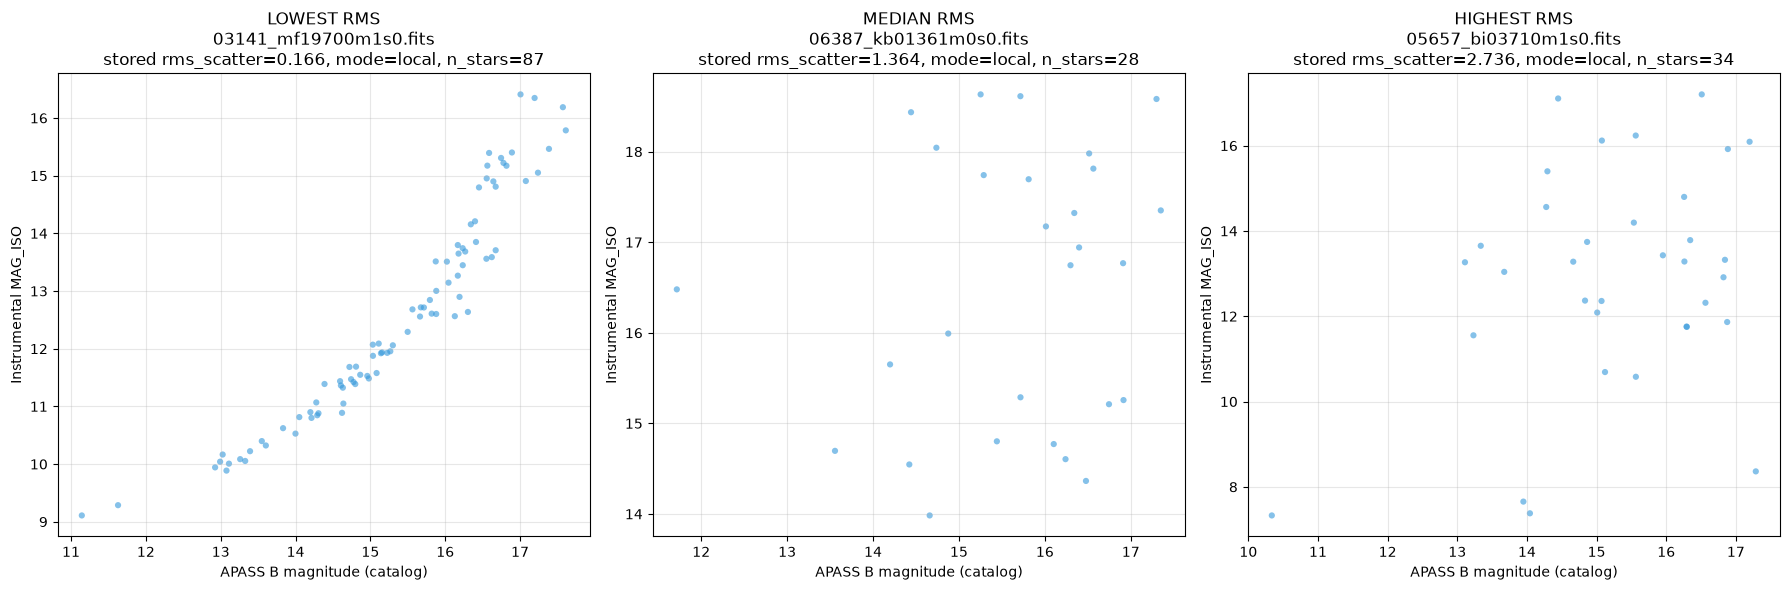


What to look for:
- If HIGHEST RMS plate visibly looks messier/scattered/multi-branch
  compared to LOWEST - the RMS number is measuring something real,
  and we need to figure out why so many plates fall in that regime.
- If HIGHEST RMS plate ALSO looks clean and tight, similar to LOWEST -
  that's a strong sign the rms_scatter VALUE ITSELF is being computed
  or stored incorrectly somewhere, not that the data is actually bad.


In [ ]:
# One-off diagnostic v2 - NOT part of the pipeline, run standalone.
# Uses files already saved by your last run - no reprocessing needed.
# Last time we plotted the plate with the MOST reference stars, which is
# likely a best-case, non-representative plate. This time we pick plates
# by their ACTUAL recorded RMS - lowest, closest-to-median, and highest -
# so we can see whether bad-RMS plates actually look different from the
# clean one we already saw, or whether something else is going on.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results_df = pd.read_csv(RESULTS_PATH)
ref_df = pd.read_csv(REF_PHOTOMETRY_PATH)

detected = results_df[results_df['target_detected'] & results_df['rms_scatter'].notna()].copy()
detected = detected.sort_values('rms_scatter').reset_index(drop=True)
print(f"{len(detected)} target-detected plates with a recorded RMS")

n = len(detected)
picks = {
    'LOWEST RMS': detected.iloc[0],
    'MEDIAN RMS': detected.iloc[n // 2],
    'HIGHEST RMS': detected.iloc[-1],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (label, row) in zip(axes, picks.items()):
    fname = row['filename']
    rms = row['rms_scatter']
    mode = row['calibration_mode']
    plate_data = ref_df[ref_df['filename'] == fname]
    ax.scatter(plate_data['apass_b_mag'], plate_data['instrumental_mag'],
               s=20, alpha=0.6, color='#3498db', edgecolor='none')
    ax.set_xlabel('APASS B magnitude (catalog)')
    ax.set_ylabel('Instrumental MAG_ISO')
    ax.set_title(f'{label}\n{fname}\nstored rms_scatter={rms:.3f}, mode={mode}, n_stars={len(plate_data)}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nWhat to look for:")
print("- If HIGHEST RMS plate visibly looks messier/scattered/multi-branch")
print("  compared to LOWEST - the RMS number is measuring something real,")
print("  and we need to figure out why so many plates fall in that regime.")
print("- If HIGHEST RMS plate ALSO looks clean and tight, similar to LOWEST -")
print("  that's a strong sign the rms_scatter VALUE ITSELF is being computed")
print("  or stored incorrectly somewhere, not that the data is actually bad.")